In [15]:
import os
os.getcwd()
import constants

In [12]:
import silmaril
import astropy
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

s = astropy.coordinates.SkyCoord(24.3468342,-8.4645026,unit="deg")
image_plane = silmaril.Grid(s,1000,0.031) # 0.031 arcseconds per pixel, 1000 pixels
wcs = astropy.wcs.WCS(astropy.io.fits.open(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")[0].header)
x_deflections = silmaril.open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_x-arcsec-deflect.fits")
y_deflections = silmaril.open_fits(r"./silmaril_playground/hlsp_relics_model_model_whl0137m08_glafic_v1_y-arcsec-deflect.fits")

# fits file is the standard for astronomy community for 

# hdul = fits.open(r"C:\\Users\\josep\Documents\\Python Projects\\hlsp_relics_model_whl0137-08_glafic_v1_x-arcsec-deflect.fits")
# hdul.info()

lens = silmaril.Lens(x_deflections,y_deflections,wcs,redshift=0.566,unit='arcsec')

#Line below is characterized by the "detector"
detector = silmaril.Detector(resolution=0.031,fov=30,center=astropy.coordinates.SkyCoord(24.34819561, -8.46520946,unit="deg"),psf_fwhm=2.065)

conv = lens.convergence(image_plane,6.2)
mag_line = lens.magnification_line(image_plane,6.2)

In [16]:
import yt 
epf = [
    ("particle_family", "b"),
    ("particle_tag", "b"),
    ("particle_birth_epoch", "d"),
    ("particle_metallicity", "d"),
]

ds = yt.load(constants.SIMULATION_PATH, extra_particle_fields=epf)
ad = ds.all_data() 

yt : [INFO     ] 2026-04-13 17:47:48,365 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-04-13 17:47:48,366 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-04-13 17:47:48,367 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-04-13 17:47:48,368 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-04-13 17:47:48,369 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-04-13 17:47:48,370 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-04-13 17:47:48,370 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-04-13 17:47:48,371 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-04-13 17:47:48,371 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-04-13 17:47:48,372 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-04-13 17:47:48,495 This output

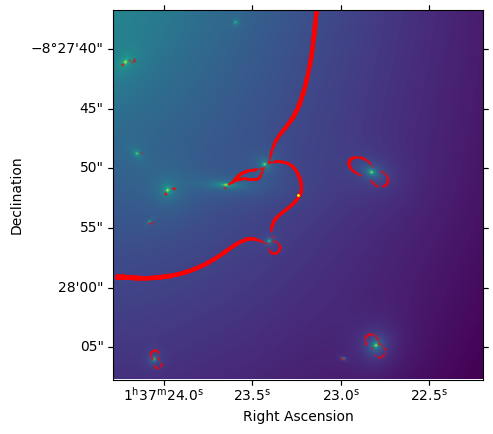

In [17]:
ax = plt.subplot(projection=image_plane.wcs)
ax.imshow(np.log10(abs(conv)),origin="lower")
 # Color shows distribution of mass in the lens plane; start with angles and derive mass per unit area
ax.scatter(mag_line[:,0],mag_line[:,1],s=0.1,color="red",transform=ax.get_transform('world')) #Red line = caustics
ax.scatter(24.3468342,-8.4645026,s=1,color="yellow",transform=ax.get_transform('world')) # Yellow dot on red line is where the image is!
ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declination')


In [18]:
lens.trace_points([[24.3468342,-8.4645026]],6.2)

array([24.35380691, -8.45843597])

In [19]:
# Line below gives the position of the galaxy--play with this!
galaxy = silmaril.Galaxy("output_00273.txt",redshift=6.2,size=200,center=astropy.coordinates.SkyCoord(24.35378054, -8.45843384,unit="deg"),extra="/mnt/sim/output_00273/info_00273.txt"); # loads in the actual galaxy at the source plane
observation = silmaril.Observation(detector,lens,galaxy);

galaxy.plot(1000, custom = True)

# Image of the galaxy is shown below! (source plane) color = luminosity

TypeError: Galaxy.__init__() got an unexpected keyword argument 'extra'

In [ ]:
galaxy.pixel_scale(resolution=1000,zoom_factor=1)

lensed_image = observation.simulate_observation(background=3e-11,noise=5e-12,source_resolution=1000,star_by_star=True, filter_name="F200W")
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=False,custom=True, filter_name="F277W")

# Actual lensed image simulation

yt : [INFO     ] 2026-03-23 18:04:47,155 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
yt : [INFO     ] 2026-03-23 18:04:47,250 Identified 1 intersecting domains
yt : [INFO     ] 2026-03-23 18:04:55,310 Projection completed
yt : [INFO     ] 2026-03-23 18:04:55,320 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,321 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,326 xlim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,327 ylim = 0.000000 1.000000
yt : [INFO     ] 2026-03-23 18:04:55,328 Making a fixed resolution buffer of (('deposit', 'star_sum_lum_F277W')) 1000 by 1000


(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

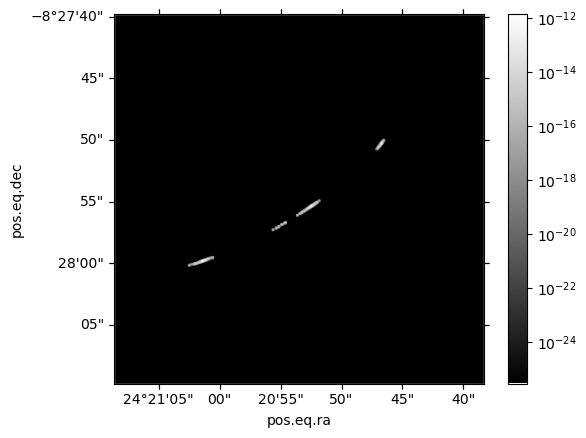

In [ ]:
observation.plot(background=0,noise=0,source_resolution=1000,star_by_star=True,filter_name="F277W")

(<Figure size 640x480 with 2 Axes>, <WCSAxes: >)

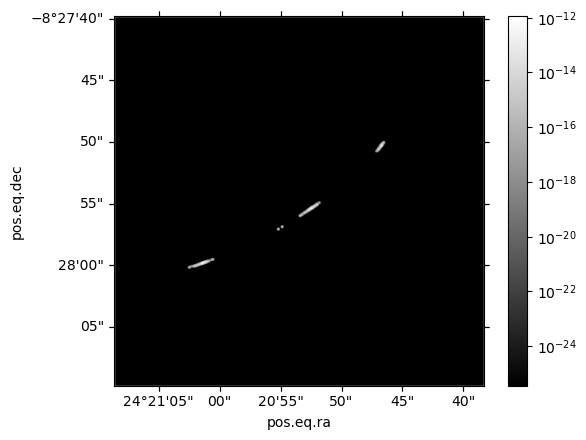

In [12]:
observation.plot(background=0,noise=0,source_resolution=1000,filter_name="F070W")

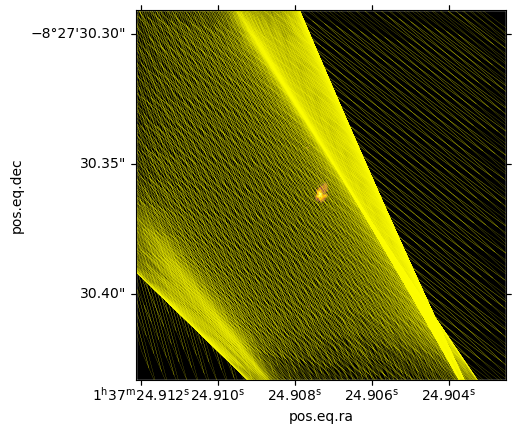

In [10]:

from matplotlib.patches import Polygon
import matplotlib as mpl
from matplotlib.colors import LogNorm
nonempty_pixels, arc_pixels, polygons, luminosities = observation.trace_pixels(source_resolution=1000,zoom_factor=2)

ax = plt.subplot(projection=galaxy.grid(1000,2).wcs)
ax.imshow(galaxy.create_image(resolution=1000,zoom_factor=2),norm=LogNorm(1e-9,1e-7),cmap="inferno")
polygons = [Polygon(p,closed=True,fill=False,color="yellow",lw=0.1,transform=ax.get_transform('world')) for p in polygons]

ax.set_facecolor('black')
for i,p in enumerate(polygons):
    ax.add_patch(p)

    #Image shows grid overlayed on the galaxy (lines are actually elongated grids)